In [1]:
%cd ../../

/Users/paulb/Desktop/code/research/babi


In [2]:
import os
import pandas as pd
from data import constants, plotting
import numpy as np

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}
40405 samples (2020.25 seconds)


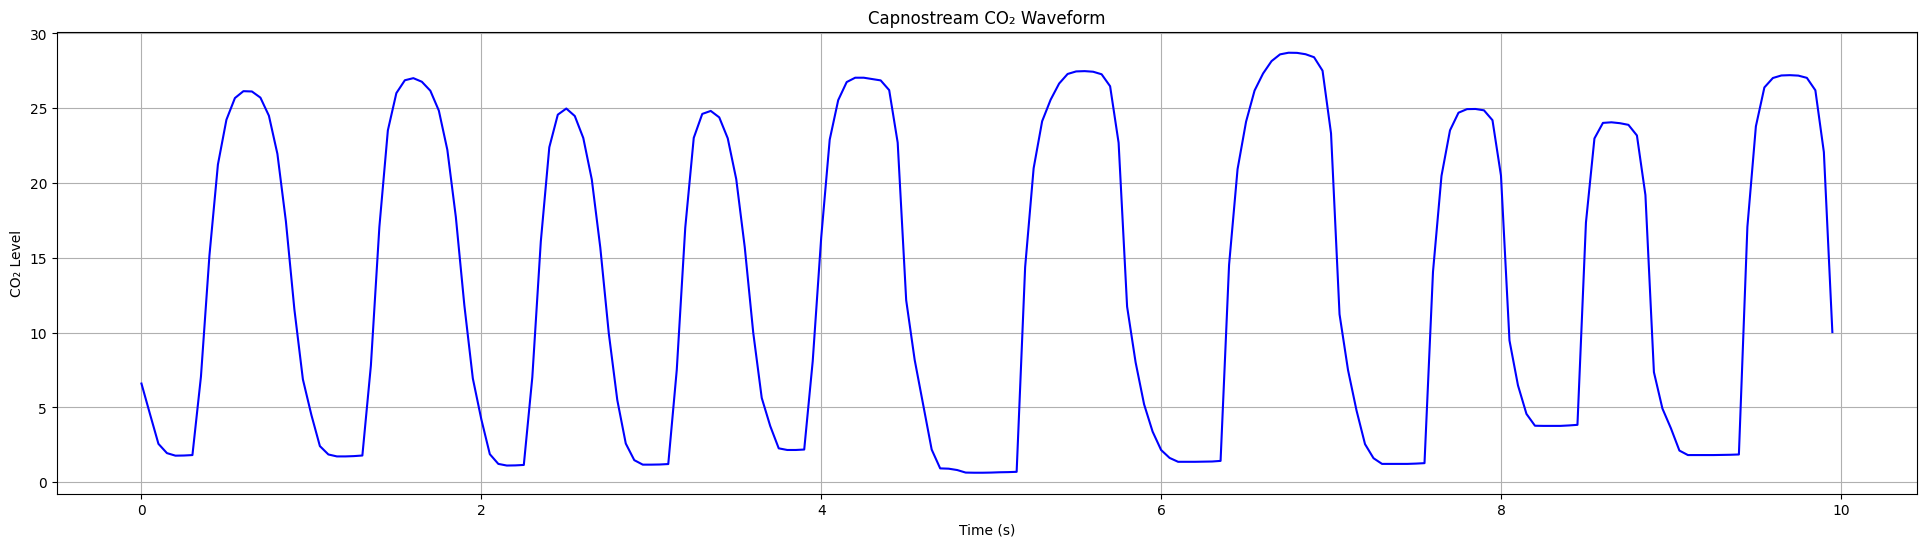

In [3]:
first_preprocessed_capnostream_file = os.listdir(os.path.join(constants.preprocessed_data_dir, "capnostream"))[1]
capnostream_file_df: pd.DataFrame = pd.read_pickle(os.path.join(constants.preprocessed_data_dir, "capnostream", first_preprocessed_capnostream_file))
signal = capnostream_file_df["co2_wave"].to_numpy()
print(capnostream_file_df.attrs) # show metadata
print(f"{len(signal)} samples ({len(signal) / constants.capnostream_sampling_rate:.2f} seconds)")
plotting.plot_capnostream_waveform(data=capnostream_file_df["co2_wave"][:200])

Constraint 'min_amplitude' failures: 18263
Constraint 'plateau_slope_tolerance' failures: 18271
Constraint 'plateau_vertical_tolerance' failures: 433
Constraint 'min_length' failures: 1835
Constraint 'max_units_from_zero' failures: 132
Constraint 'unit_max_amplitude' failures: 288
Constraint 'mean_max_amplitude_error_percentage' failures: 0
Extracted 721 units from capnostream signal.
Min unit length: 0.65 seconds.
Max unit length: 1.50 seconds.
Mean unit length: 1.18 seconds.
Total unit length: 14.12 minutes.
Total signal length: 33.67 minutes.


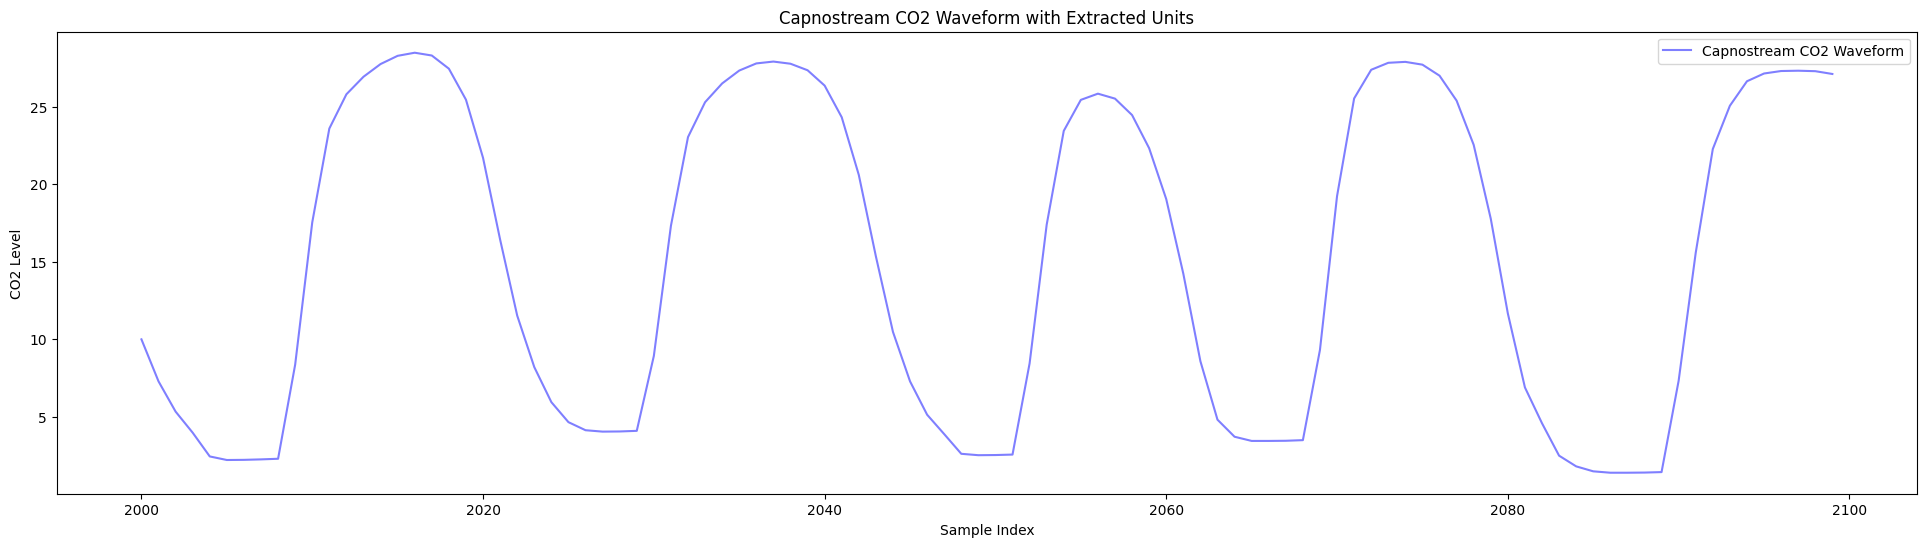

Unit 1: 5584 to 5604 (1.00 seconds)


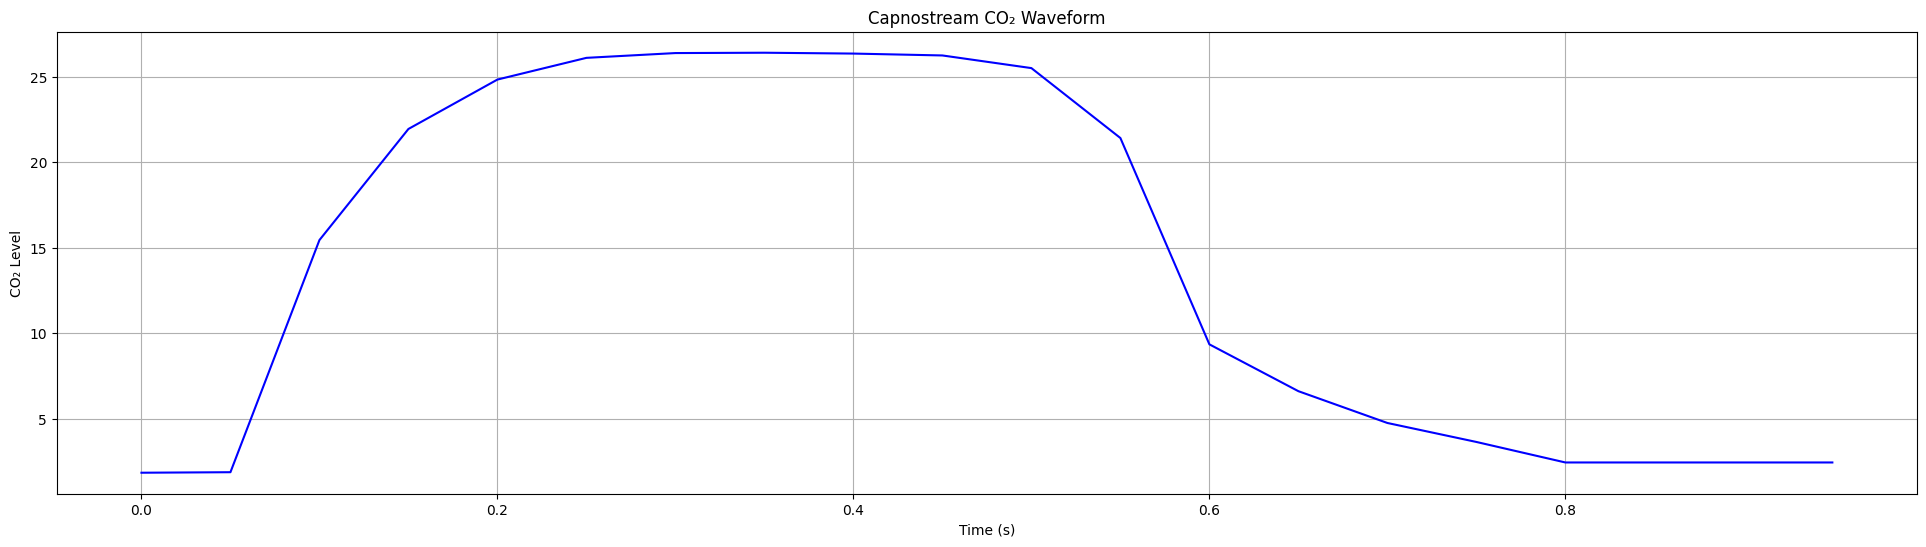

Unit 2: 5604 to 5621 (0.85 seconds)


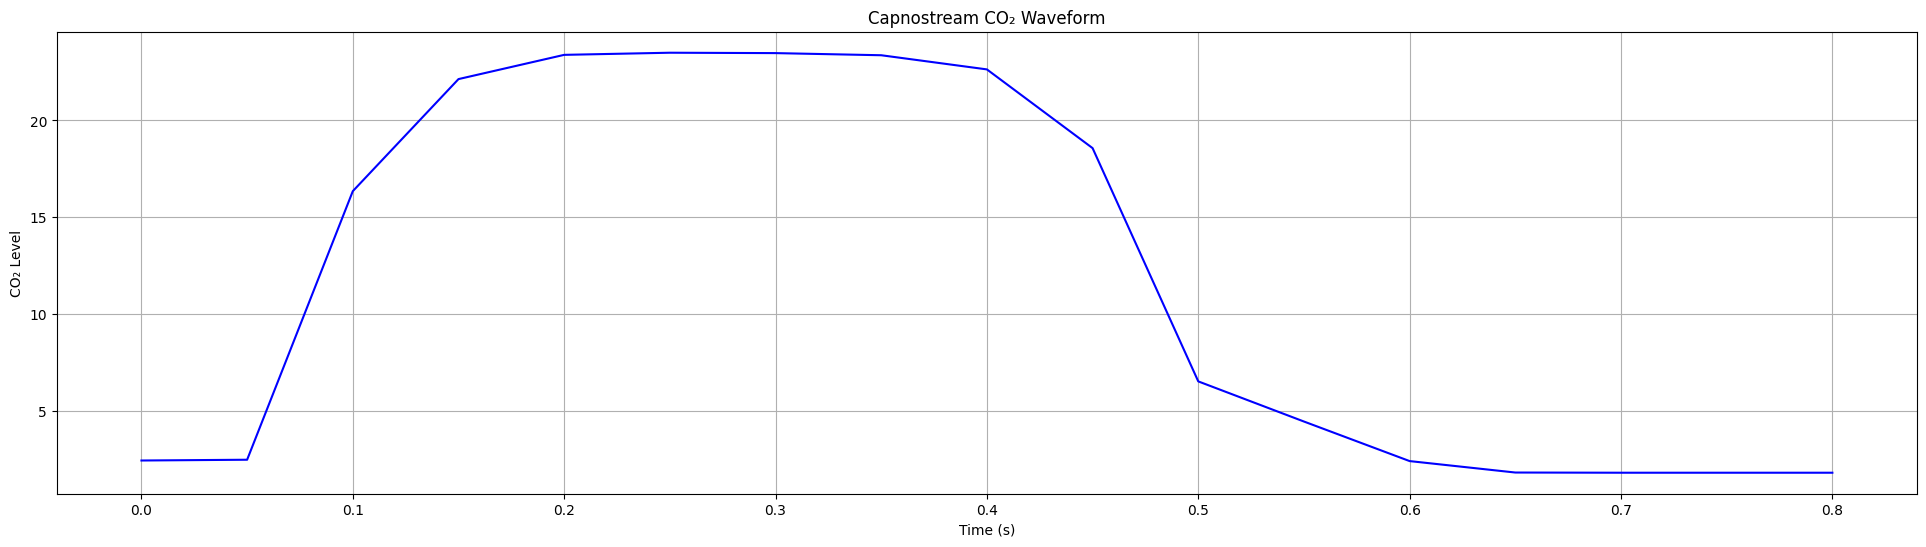

Unit 3: 5621 to 5643 (1.10 seconds)


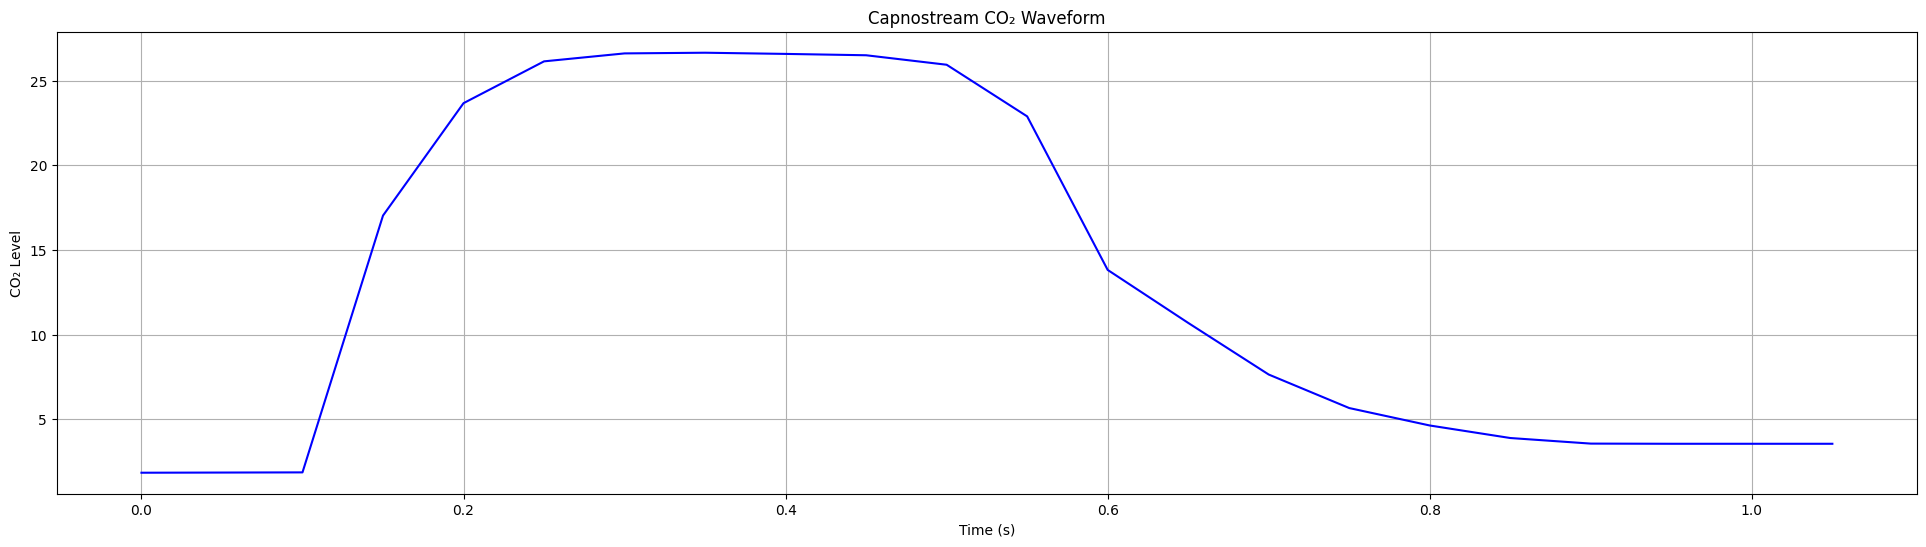

Unit 4: 5643 to 5662 (0.95 seconds)


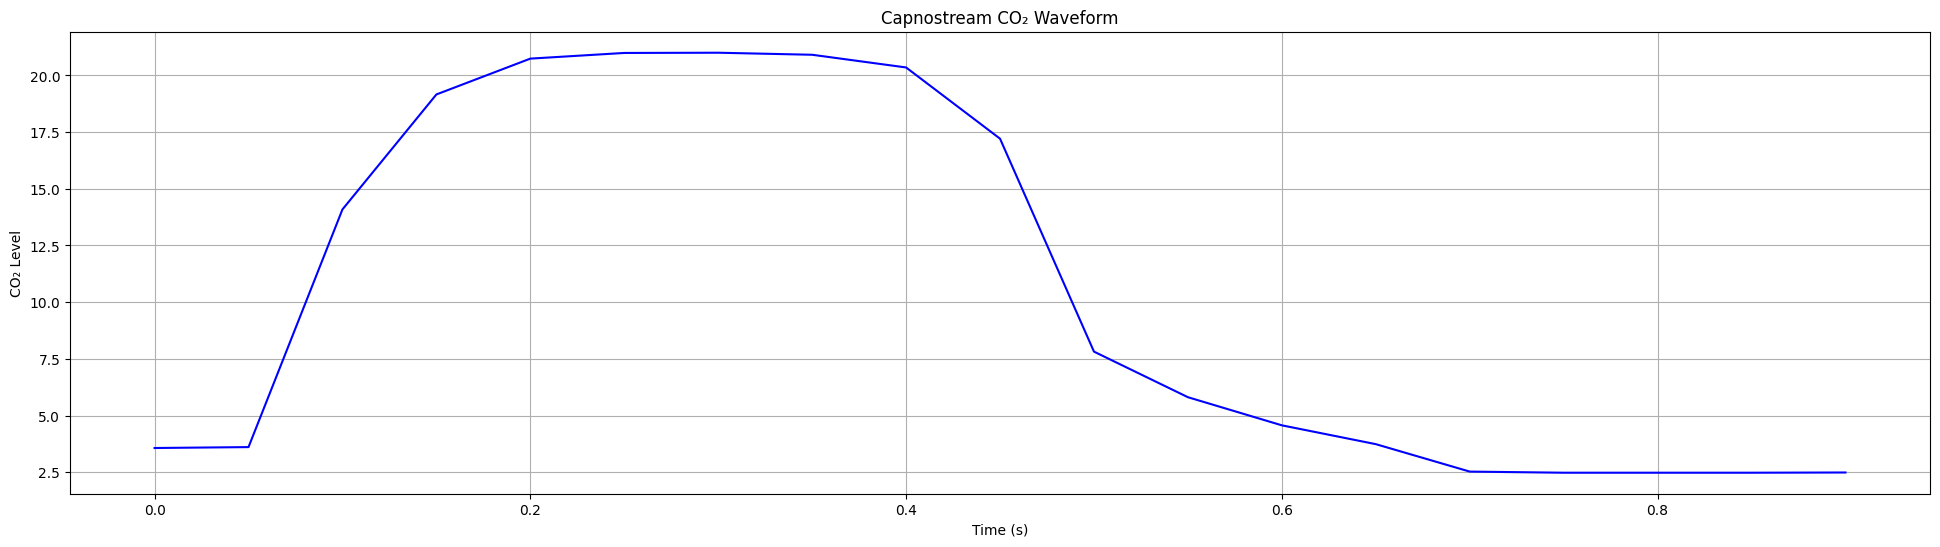

Unit 5: 5705 to 5728 (1.15 seconds)


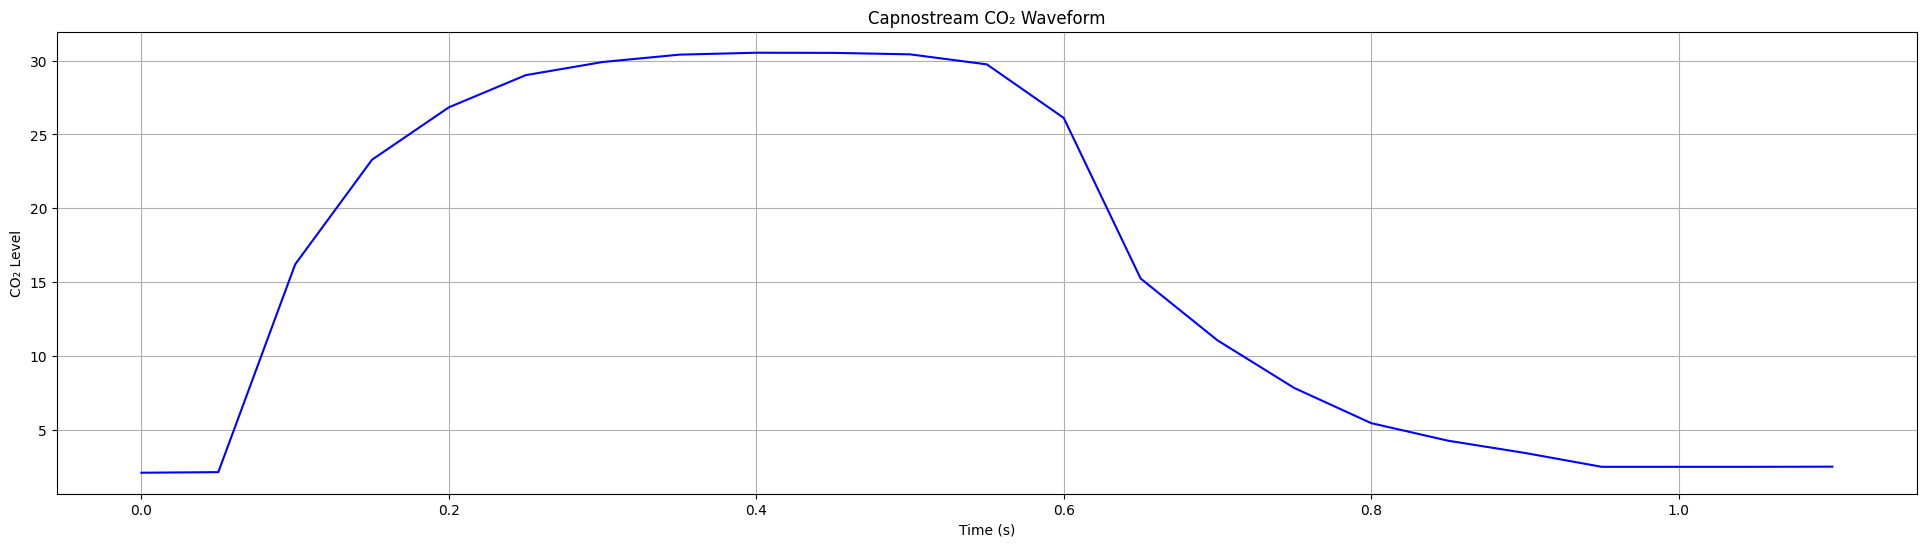

In [4]:
min_length = 0.4 * constants.capnostream_sampling_rate # minimum length of unit (also distance between plateaus) (s)
slope_window = 4 # windowed samples to calculate slope
plateau_slope_tolerance = 0.01 # within x unit(s) of zero-slope
min_amplitude = 16 # minimum amplitude between initial marker and unit max value (peak)
plateau_vertical_tolerance = 2 # within x unit(s) of previous plateau
max_units_from_zero = 5 # how far the bases can be from zero 
mean_max_amplitude_error_percentage = 0.7 # % error allowed between mean amplitude and unit max amplitude (ideally ~40%)
max_search_before_discard = 1.5 * constants.capnostream_sampling_rate # if no plateau found within this length, discard unit and find the next one (s)

def extract_unit_markers(signal: np.ndarray) -> list[tuple[int, int]]:
    """Extract 'breathing' units by capturing segments between low plateaus"""
    position = slope_window - 1
    units: list[tuple[int, int]] = []
    constraint_failure_count = {
        "min_amplitude": 0,
        "plateau_slope_tolerance": 0,
        "plateau_vertical_tolerance": 0,
        "min_length": 0,
        "max_units_from_zero": 0,
        "unit_max_amplitude": 0,
        "mean_max_amplitude_error_percentage": 0,
    }

    marker = (-1, 0) # (index, mean amplitude)
    while position < len(signal):
        position += 1
        sample = signal[position-slope_window:position]
        mean_amplitude = np.mean(sample)

        # amplitude of this sample is too high
        if mean_amplitude > min_amplitude: 
            constraint_failure_count["min_amplitude"] += 1
            continue
        
        slope = np.mean(np.diff(sample))
        
        # slope not close enough to zero
        if abs(slope) > plateau_slope_tolerance:
            constraint_failure_count["plateau_slope_tolerance"] += 1
            continue

        # marker doesn't exist yet or max search distance reached -> create without other checks
        if marker[0] == -1 or position - marker[0] > max_search_before_discard:
            marker = (position, mean_amplitude)
            continue
        
        # not within vertical tolerance of previous plateau
        if abs(mean_amplitude - marker[1]) > plateau_vertical_tolerance: 
            constraint_failure_count["plateau_vertical_tolerance"] += 1
            continue

        # not enough distance from previous marker
        if position - marker[0] < min_length: 
            constraint_failure_count["min_length"] += 1
            continue 

        unit_sample = signal[marker[0]:position]
        unit_max_amplitude, unit_mean_amplitude = np.max(unit_sample), np.mean(unit_sample)

        # max amplitude within unit not high enough
        if unit_max_amplitude < min_amplitude: 
            constraint_failure_count["unit_max_amplitude"] += 1
            continue 
        
        # mean and max amplitude too far
        if abs(unit_mean_amplitude - unit_max_amplitude) > unit_max_amplitude * mean_max_amplitude_error_percentage: 
            constraint_failure_count["mean_max_amplitude_error_percentage"] += 1
            continue

        if marker[1] > max_units_from_zero or mean_amplitude > max_units_from_zero:
            constraint_failure_count["max_units_from_zero"] += 1
            continue

        units.append((marker[0], position)) # store valid unit
        marker = (position, mean_amplitude) # update marker to current position
        # print(f"Position: {position}, Mean Amplitude: {mean_amplitude:.2f}, Slope: {slope:.4f}")

    for constraint, count in constraint_failure_count.items():
        print(f"Constraint '{constraint}' failures: {count}")

    return units

unit_markers = extract_unit_markers(capnostream_file_df["co2_wave"].to_numpy())
print(f"Extracted {len(unit_markers)} units from capnostream signal.")
mean_unit_length = np.mean([end-start for start, end in unit_markers])
max_unit_length = np.max([end-start for start, end in unit_markers])
min_unit_length = np.min([end-start for start, end in unit_markers])
total_unit_length = np.sum([end-start for start, end in unit_markers])

print(f"Min unit length: {min_unit_length/constants.capnostream_sampling_rate:.2f} seconds.")
print(f"Max unit length: {max_unit_length/constants.capnostream_sampling_rate:.2f} seconds.")
print(f"Mean unit length: {mean_unit_length/constants.capnostream_sampling_rate:.2f} seconds.")
print(f"Total unit length: {total_unit_length/constants.capnostream_sampling_rate/60:.2f} minutes.")
print(f"Total signal length: {len(capnostream_file_df['co2_wave'])/constants.capnostream_sampling_rate/60:.2f} minutes.")

import matplotlib.pyplot as plt

view_range = (2000, 2100)

plt.figure(figsize=(24, 6))
plt.plot(capnostream_file_df["co2_wave"][view_range[0]:view_range[1]], label="Capnostream CO2 Waveform", color="blue", alpha=0.5)
for i, (start, end) in enumerate(unit_markers):
    if start > view_range[0] and end < view_range[1]:
        plt.axvspan(start, end, color="orange", alpha=0.3)
plt.title("Capnostream CO2 Waveform with Extracted Units")
plt.xlabel("Sample Index")
plt.ylabel("CO2 Level")
plt.legend()
plt.show()

view_start = 40
for i, (start, end) in enumerate(unit_markers[view_start:view_start+5]):
    print(f"Unit {i+1}: {start} to {end} ({(end-start)/constants.capnostream_sampling_rate:.2f} seconds)")
    plotting.plot_capnostream_waveform(data=capnostream_file_df["co2_wave"][start:end])


# todo: skew factor that condenses the waveform for the model (also a param)

Extracted 721 unit signals.
Augmentation type: raw


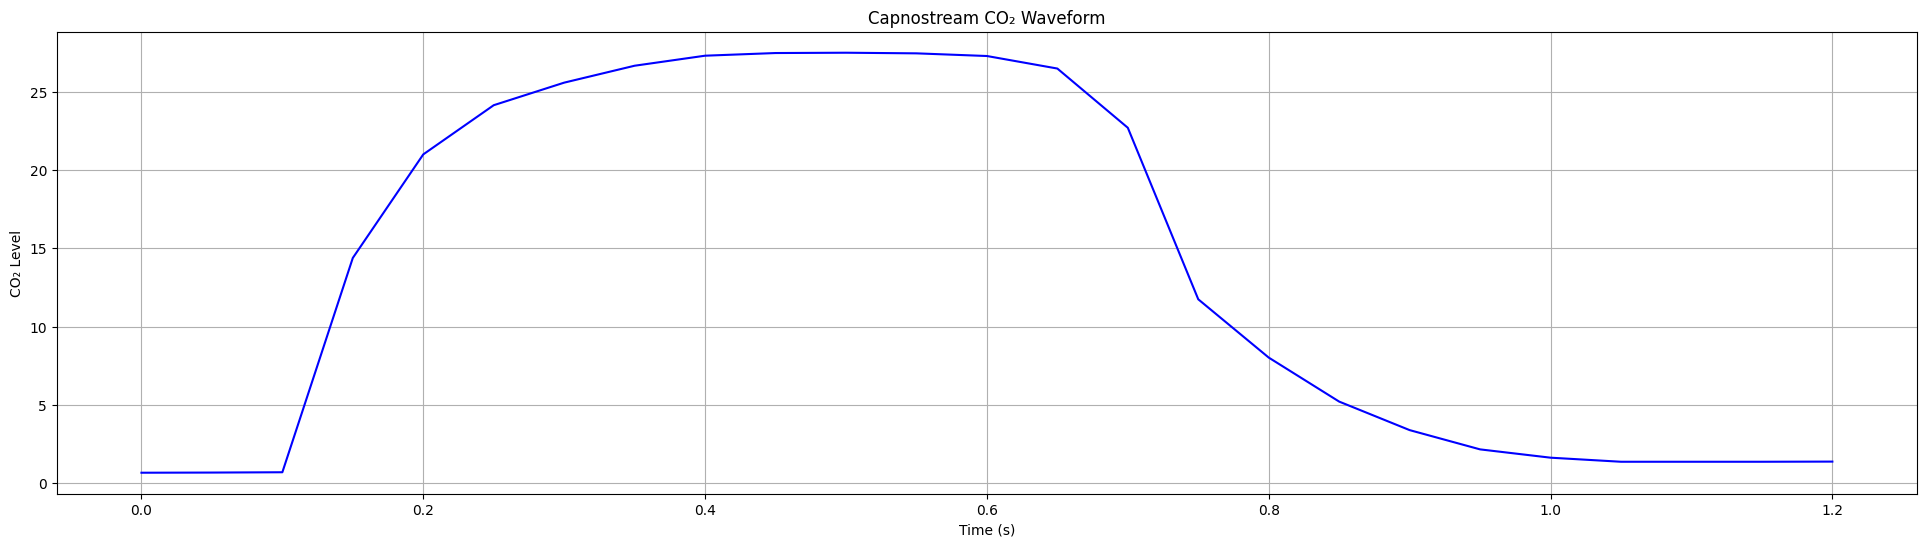

Augmentation type: scale


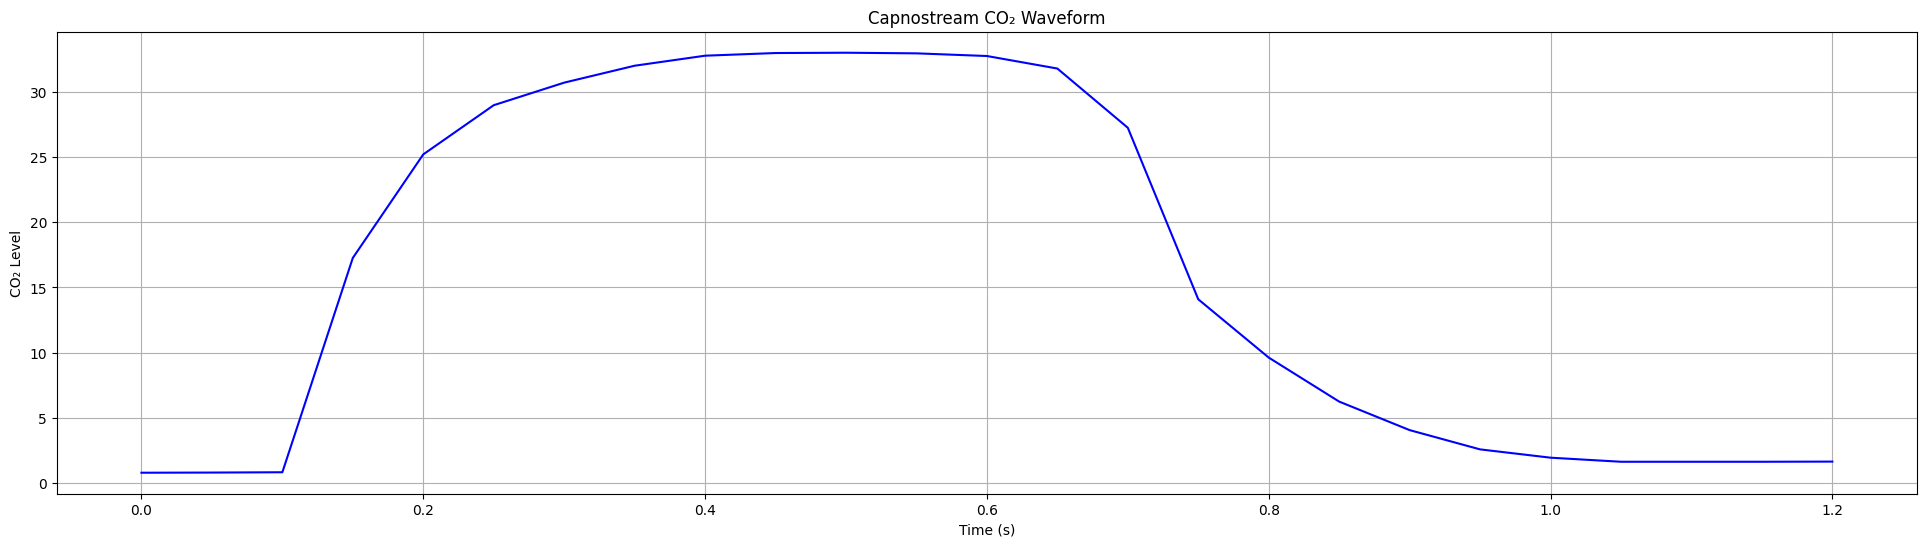

Augmentation type: roll


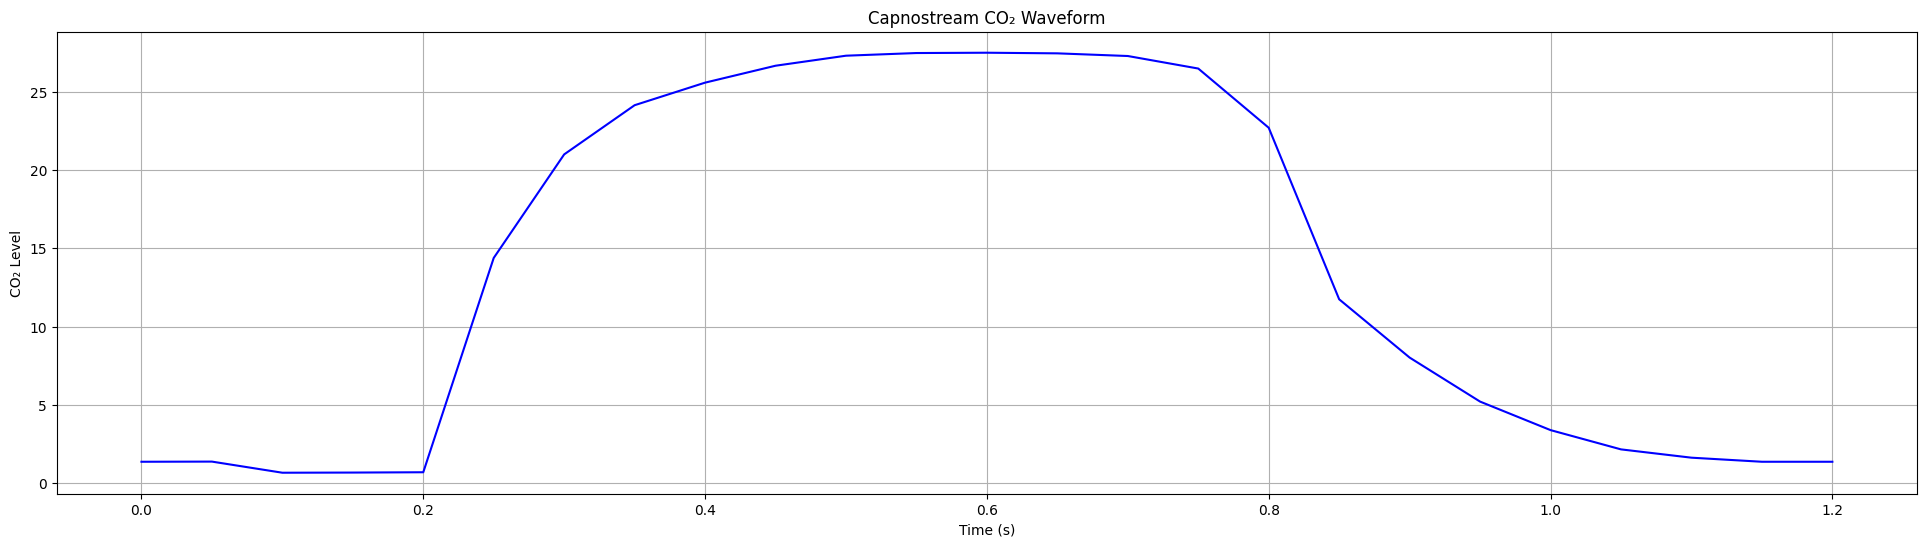

Augmentation type: noise


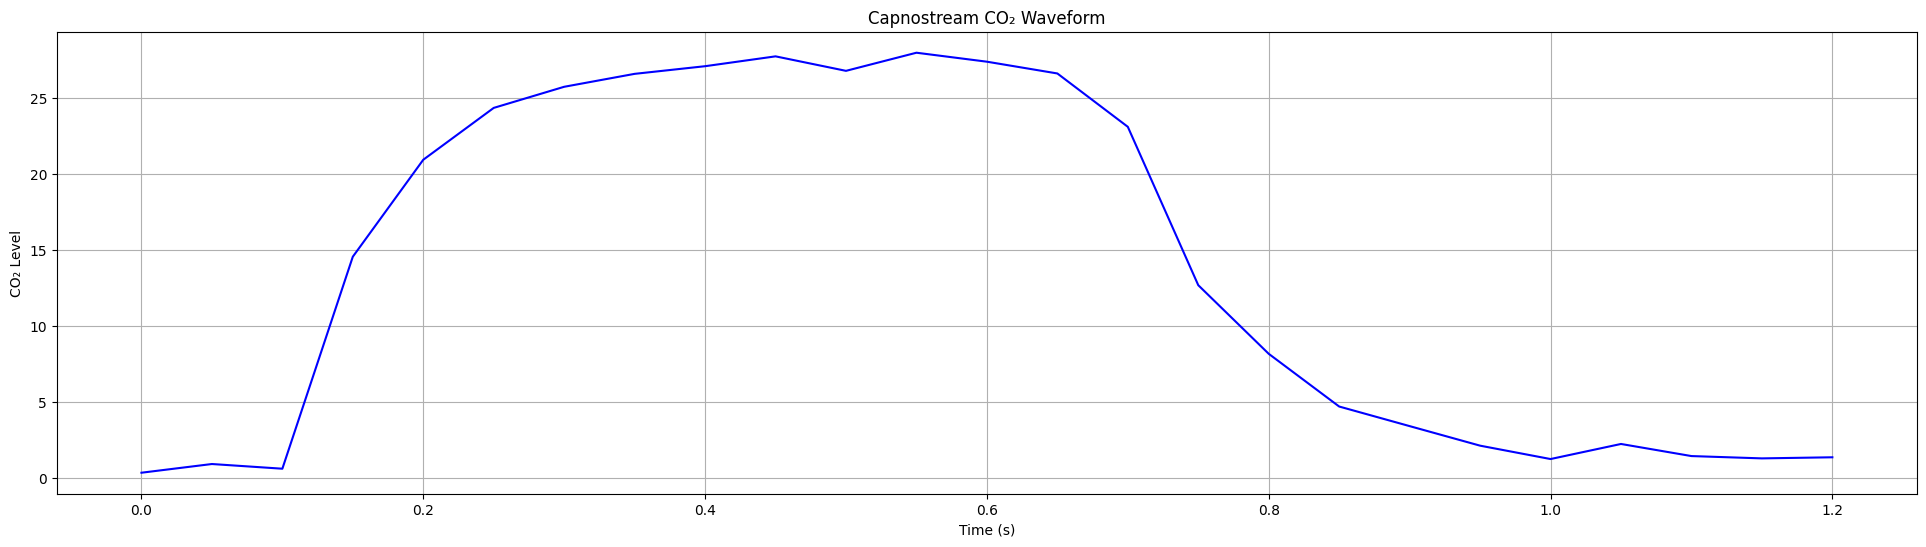

Augmentation type: stretch-wide


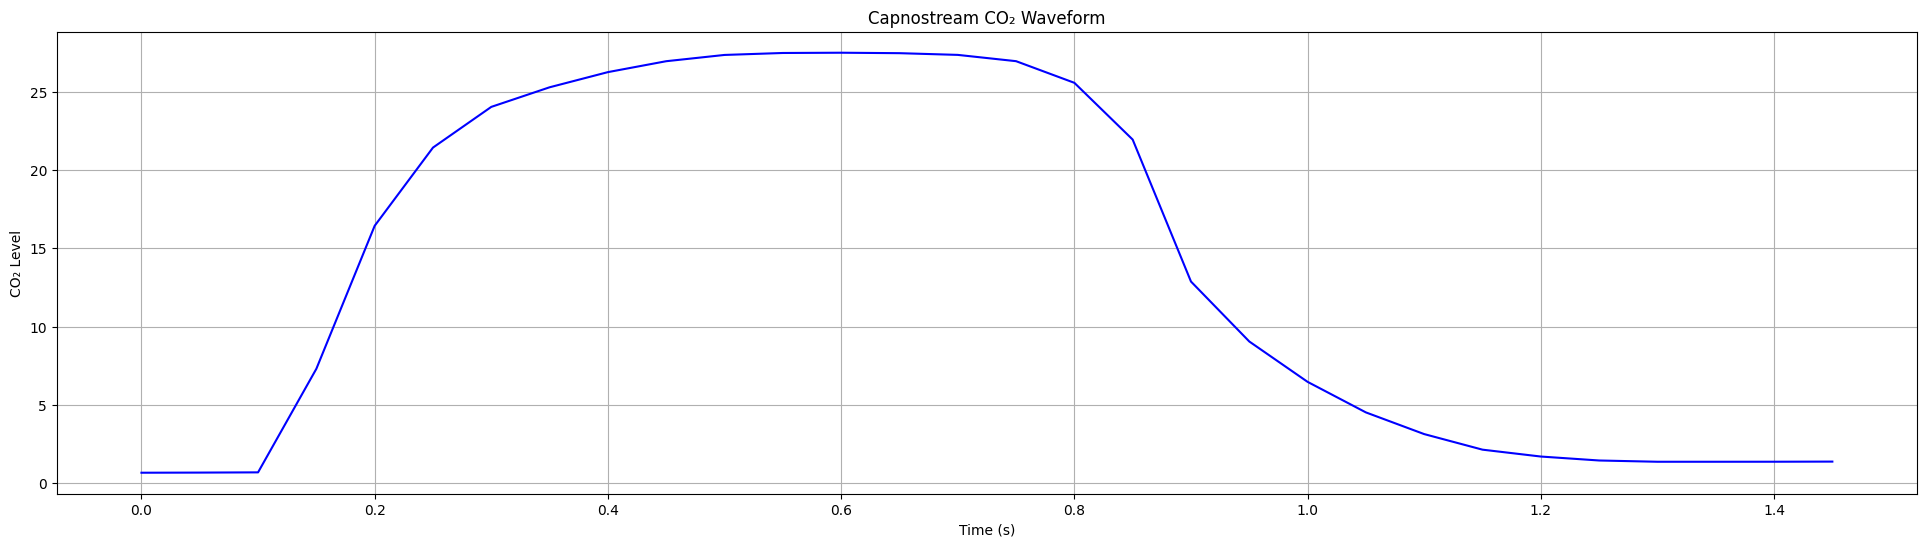

Augmentation type: stretch-narrow


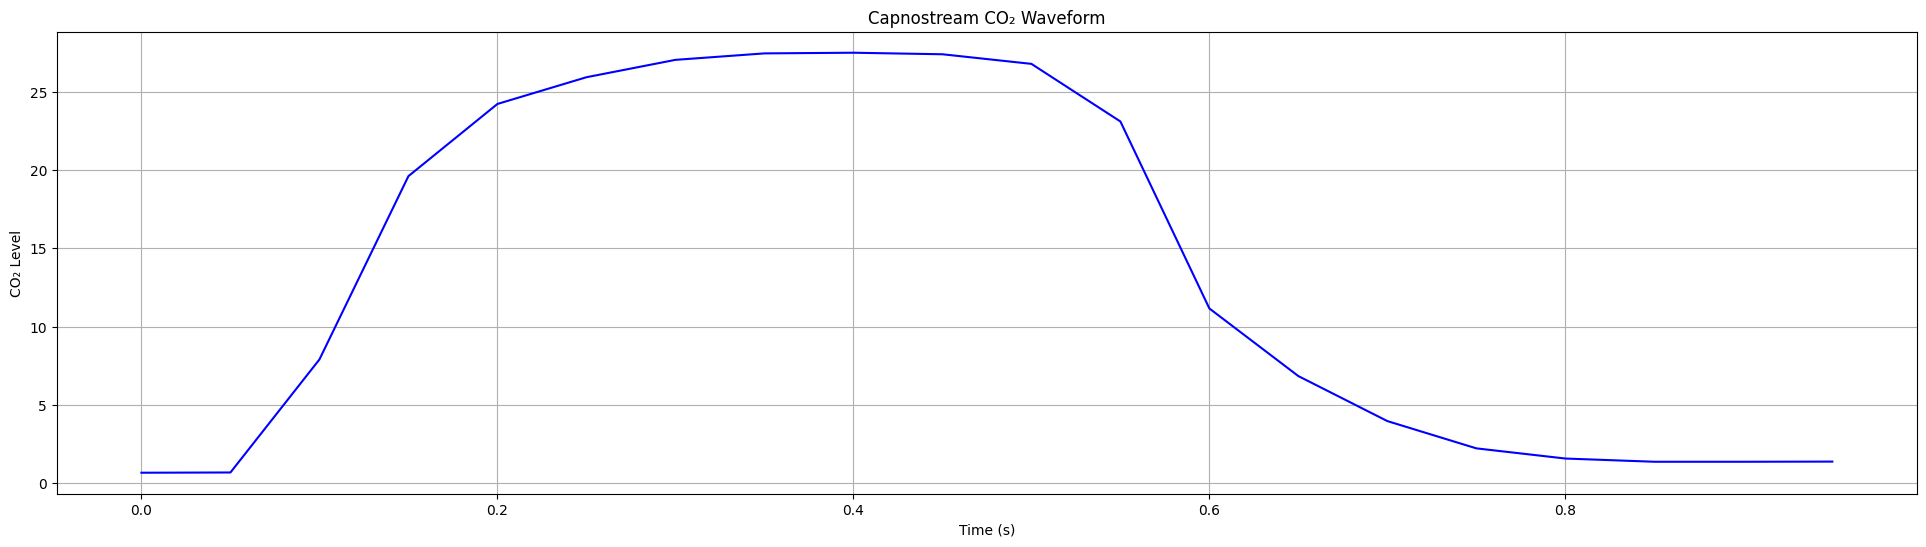

Augmentation type: all


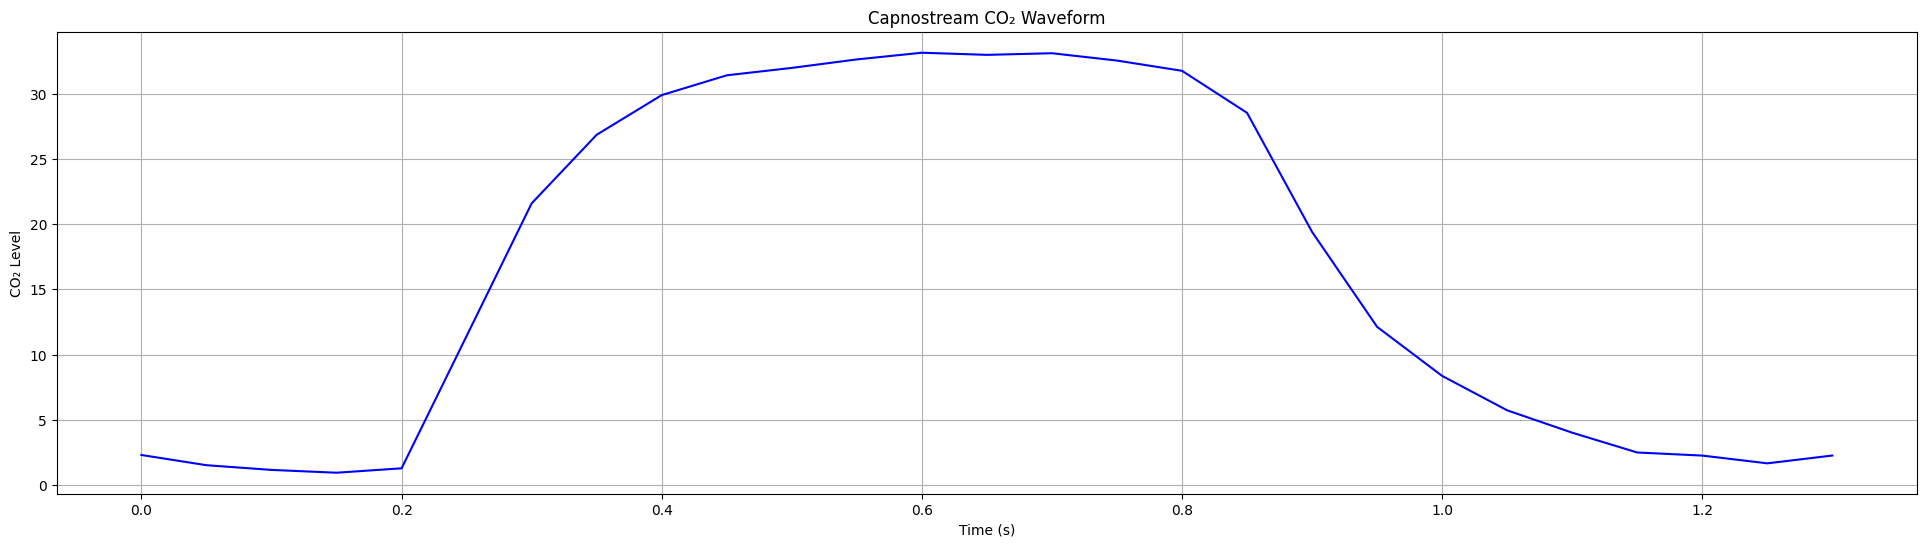

In [5]:
def scale(signal: np.ndarray, scale_factor: float) -> np.ndarray:
    """Scale the amplitude of the signal by scale_factor"""
    return signal * scale_factor

def roll(signal: np.ndarray, roll_amount: int) -> np.ndarray:
    """Time shift the signal by roll_amount samples"""
    return np.roll(signal, roll_amount)

def noise(signal: np.ndarray, noise_level: float) -> np.ndarray:
    """Add random noise to the signal"""
    noise = np.random.normal(0, noise_level, size=signal.shape)
    return signal + noise

def stretch(signal: np.ndarray, stretch_factor: float) -> np.ndarray:
    """Stretch or compress the signal in time by stretch_factor using simple indexing"""
    from scipy.interpolate import interp1d
    new_length = int(len(signal) * stretch_factor)
    new_time = np.linspace(0, len(signal) - 1, new_length)

    interpolator = interp1d(np.arange(len(signal)), signal, kind='linear')
    return interpolator(new_time)

signals = [signal[start:end] for start, end in unit_markers]
print(f"Extracted {len(signals)} unit signals.")

raw_signal = signals[0]

augmented_signals = {
    "raw": raw_signal,
    "scale": scale(raw_signal, scale_factor=1.2),
    "roll": roll(raw_signal, roll_amount=2),
    "noise": noise(raw_signal, noise_level=0.4),
    "stretch-wide": stretch(raw_signal, stretch_factor=1.2),
    "stretch-narrow": stretch(raw_signal, stretch_factor=0.8),
    "all": stretch(noise(scale(roll(raw_signal, roll_amount=2), scale_factor=1.2), noise_level=0.4), stretch_factor=1.1),
}


for aug_type, aug_signal in augmented_signals.items():
    print(f"Augmentation type: {aug_type}")
    plotting.plot_capnostream_waveform(data=aug_signal)
